Packages importeren en zorgen dat output niet wordt onderbroken door puntjes

In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import altair as alt
import pickle
import gdown
import matplotlib.pyplot as plt

Pickle file ophalen

In [2]:
with open('../data/supermarket_combined_sales.pkl', 'rb') as pickle_file:
    sales = pickle.load(pickle_file)

combined_sales  = sales['combined_sales']

Overige data ophalen

In [3]:
shared_url = f'https://drive.google.com/file/d/10Q0ZCqkqt91xQU4VRvFHdatxNkUi8A2E/view?usp=drive_link'

file_id = shared_url.split('/d/')[1].split('/')[0]
download_url = f'https://drive.google.com/uc?id={file_id}'

output = 'items.parquet'
gdown.download(download_url, output, quiet=False)

items = pd.read_parquet(output)
print(items.head())

shared_url = f'https://drive.google.com/file/d/1yLFRvstJ2-XbeTIGfe6i47l4z_qu8iY8/view?usp=drive_link'

file_id = shared_url.split('/d/')[1].split('/')[0]
download_url = f'https://drive.google.com/uc?id={file_id}'

output = 'stores.parquet'
gdown.download(download_url, output, quiet=False)

stores = pd.read_parquet(output)
print(stores.head())

Downloading...
From: https://drive.google.com/uc?id=10Q0ZCqkqt91xQU4VRvFHdatxNkUi8A2E
To: c:\Users\m.muller\Documents\Python\Projects\Supermarket CFGS\Code\items.parquet
100%|██████████| 25.9k/25.9k [00:00<00:00, 26.1MB/s]


   item_nbr        family  class  perishable
0     96995     GROCERY I   1093           0
1     99197     GROCERY I   1067           0
2    103501      CLEANING   3008           0
3    103520     GROCERY I   1028           0
4    103665  BREAD/BAKERY   2712           1


Downloading...
From: https://drive.google.com/uc?id=1yLFRvstJ2-XbeTIGfe6i47l4z_qu8iY8
To: c:\Users\m.muller\Documents\Python\Projects\Supermarket CFGS\Code\stores.parquet
100%|██████████| 4.77k/4.77k [00:00<00:00, 4.79MB/s]

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


Verkleinen geheugengebruik door types aan te passen

In [7]:
for col in combined_sales.select_dtypes(include=["object"]).columns:
    combined_sales[col] = combined_sales[col].astype("category")

for col in combined_sales.select_dtypes(include=["number"]).columns:
    combined_sales[col] = pd.to_numeric(combined_sales[col], downcast="integer")
    combined_sales[col] = pd.to_numeric(combined_sales[col], downcast="float")

for col in items.select_dtypes(include=["object"]).columns:
    items[col] = items[col].astype("category")

for col in items.select_dtypes(include=["number"]).columns:
    items[col] = pd.to_numeric(items[col], downcast="integer")
    items[col] = pd.to_numeric(items[col], downcast="float")

for col in stores.select_dtypes(include=["object"]).columns:
    stores[col] = stores[col].astype("category")

for col in stores.select_dtypes(include=["number"]).columns:
    stores[col] = pd.to_numeric(stores[col], downcast="integer")
    stores[col] = pd.to_numeric(stores[col], downcast="float")

Combineren van sales met items en stores

In [ ]:
combined_sales_items = pd.merge(combined_sales, items, on='item_nbr', how='left')
print(combined_sales_items.shape)
print()
print()


(125497040, 10)



In [ ]:
combined_sales_items_stores = pd.merge(combined_sales_items, stores, on='store_nbr', how='left')

(125497040, 14)



In [15]:
combined_sales.to_parquet("combined_history_items_stores.parquet", index=False)

Kerngetallen printen

In [10]:
print(combined_sales_items_stores.head())
print()

print(combined_sales_items_stores.shape)
print()

print(combined_sales_items_stores['onpromotion'].value_counts())
print()

missende_aantal = combined_sales_items_stores.isnull().sum()
missende_aantal = missende_aantal[missende_aantal > 0]
print(missende_aantal)


   id  store_nbr  item_nbr  unit_sales  onpromotion  day    month  \
0   0         25  103665.0         7.0         <NA>    1  2013-01   
1   1         25  105574.0         1.0         <NA>    1  2013-01   
2   2         25  105575.0         2.0         <NA>    1  2013-01   
3   3         25  108079.0         1.0         <NA>    1  2013-01   
4   4         25  108701.0         1.0         <NA>    1  2013-01   

         family  class  perishable     city        state type  cluster  
0  BREAD/BAKERY   2712           1  Salinas  Santa Elena    D        1  
1     GROCERY I   1045           0  Salinas  Santa Elena    D        1  
2     GROCERY I   1045           0  Salinas  Santa Elena    D        1  
3     GROCERY I   1030           0  Salinas  Santa Elena    D        1  
4          DELI   2644           1  Salinas  Santa Elena    D        1  

(125497040, 14)

onpromotion
False    96028767
True      7810622
Name: count, dtype: Int64

onpromotion    21657651
dtype: int64


Grafiek maken van verkopen per maand

In [12]:
monthly_sales = combined_sales_items_stores.groupby('month')['unit_sales'].sum()



C:\Users\m.muller\AppData\Local\Temp\ipykernel_8900\1067349069.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = combined_sales_items_stores.groupby('month')['unit_sales'].sum()


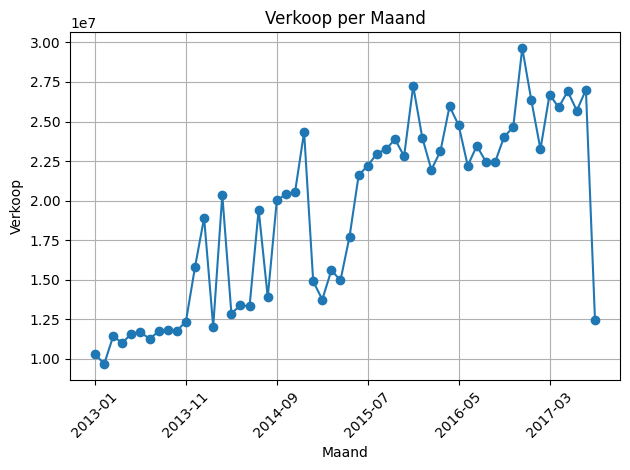

In [13]:
monthly_sales.plot(kind='line', marker='o', title='Verkoop per Maand')
plt.xlabel('Maand')
plt.ylabel('Verkoop')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Opslaan pickle file

In [14]:
dc_sales_history = {
'combined_sales_items_stores': combined_sales_items_stores,
'items': items,
'stores': stores,
}

# Save dc_exercise_1_2_3 as 'dc-ames-housing-pieter-exercise-1-2-3.pkl'
with open('../data/supermarket_combined_sales.pkl', 'wb') as pickle_file:
    pickle.dump(dc_sales_history, pickle_file)